<a href="https://colab.research.google.com/github/ada-xo-xo/dsrp/blob/main/DSRP_2026_Adanna_Oji.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [2]:
df = pd.read_csv('/content/nyt_bestsellers_combined (1).csv')
df.head(10)

,year,week,rank,title_id,title,author,pub_year,total_weeks,first_week,debut_rank,best_rank
0,1931,1931-10-12,1,6477,THE TEN COMMANDMENTS,Warwick Deeping,1931,1,1931-10-12,1,1
1,1931,1931-10-12,2,1808,FINCHE'S FORTUNE,Mazo de la Roche,1931,1,1931-10-12,2,2
2,1931,1931-10-12,3,5304,THE GOOD EARTH,Pearl S. Buck,1931,10,1931-10-12,3,1
3,1931,1931-10-12,4,4038,SHADOWS ON THE ROCK,Willa Cather,1931,1,1931-10-12,4,4
4,1931,1931-10-12,5,3946,SCARMOUCHE THE KING MAKER,Rafael Sabatini,1931,1,1931-10-12,5,5
5,1931,1931-11-16,1,2878,MAID IN WAITING,John Galsworthy,1931,9,1931-11-16,1,1
6,1931,1931-11-16,2,7031,TWO PEOPLE,A. A. Milne,1931,4,1931-11-16,2,2
7,1931,1931-11-16,3,413,AMERICAN BEAUTY,Edna Ferber,1931,2,1931-11-16,3,2
8,1931,1931-11-16,4,859,BROOME STAGES,Clemance Dane,1931,3,1931-11-16,4,2
9,1931,1931-11-16,5,4235,SPARKS FLY UPWARD,Oliver LaFarge,1931,1,1931-11-16,5,5


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60386 entries, 0 to 60385
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   year         60386 non-null  int64 
 1   week         60386 non-null  object
 2   rank         60386 non-null  int64 
 3   title_id     60386 non-null  int64 
 4   title        60386 non-null  object
 5   author       60376 non-null  object
 6   pub_year     60386 non-null  int64 
 7   total_weeks  60386 non-null  int64 
 8   first_week   60386 non-null  object
 9   debut_rank   60386 non-null  int64 
 10  best_rank    60386 non-null  int64 
dtypes: int64(7), object(4)
memory usage: 5.1+ MB


In [4]:
total_duplicates = df.duplicated().sum()
print("Total duplicate rows: {total_duplicates}")

Total duplicate rows: {total_duplicates}


In [5]:
#There is missing data
bool_series = pd.isnull(df["author"])
missing_data = df[bool_series]
print(missing_data)

      year        week  rank  title_id  \
161   1932  1932-11-14     2      3134   
579   1934  1934-08-13     5      2221   
586   1934  1934-08-20     4      2221   
594   1934  1934-08-27     4      2221   
595   1934  1934-08-27     5      1593   
606   1934  1934-09-03     8      2221   
1139  1935  1935-12-16     8      3134   
1739  1937  1937-06-21     7        69   
1754  1937  1937-07-05     7        69   
1847  1937  1937-09-27     6        69   

                                                  title author  pub_year  \
161   MUTINY ON THE BOUNTY, Charles Nordhoff and Jam...    NaN      1932   
579   HOLY DEADLOCK,  by A. P. Herbert. (Doubleday, ...    NaN      1934   
586   HOLY DEADLOCK,  by A. P. Herbert. (Doubleday, ...    NaN      1934   
594   HOLY DEADLOCK,  by A. P. Herbert. (Doubleday, ...    NaN      1934   
595   EAST AND WEST,  by Somerset Maugham. (Doubleda...    NaN      1934   
606   HOLY DEADLOCK,  by A. P. Herbert. (Doubleday, ...    NaN      1934   
1139 

In [7]:
#Creating a visualization based on the research question: How has the average total length of time a book stays on the bestseller list changed over the decades?
#Steps: 1. Drop all columns but the total weeks and year.
#2. Group by decade, find mean of weeks
#3. Create scatter plot then go from there

df2=df.drop(columns=['best_rank','debut_rank','pub_year','author','title','title_id','rank','week'])
df_1930s = df[df["year"] < 1940]
mean_30s= df_1930s['total_weeks'].mean()

df_1940s = df2[df2["year"] .between(1940, 1949)]
mean_40s= df_1940s['total_weeks'].mean()

df_1950s = df2[df2["year"] .between(1950, 1959)]
mean_50s= df_1950s['total_weeks'].mean()

df_1960s = df2[df2["year"] .between(1960, 1969)]
mean_60s= df_1960s['total_weeks'].mean()

df_1970s = df2[df2["year"] .between(1970, 1979)]
mean_70s= df_1970s['total_weeks'].mean()

df_1980s = df2[df2["year"] .between(1980, 1989)]
mean_80s= df_1980s['total_weeks'].mean()

df_1990s = df2[df2["year"] .between(1990, 1999)]
mean_90s= df_1990s['total_weeks'].mean()

df_2000s = df2[df2["year"] .between(2000, 2009)]
mean_00s= df_2000s['total_weeks'].mean()

df_2010s = df2[df2["year"] .between(2010, 2019)]
mean_10s= df_2010s['total_weeks'].mean()

#Will exclude 2020 because the dataset doesn't have data for the rest of the decade

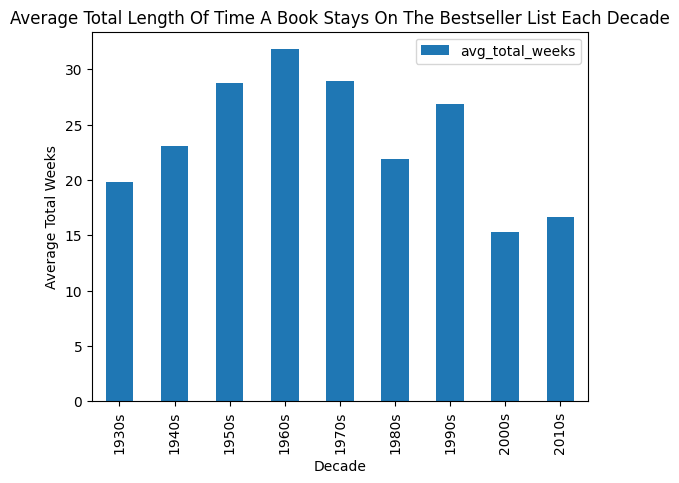

In [12]:
avg_time_per_decade_df = pd.DataFrame({
        "decade": ['1930s','1940s','1950s','1960s','1970s','1980s','1990s','2000s','2010s'],
        "avg_total_weeks": [mean_30s,mean_40s,mean_50s,mean_60s,mean_70s,mean_80s,mean_90s,mean_00s,mean_10s]
     })

avg_time_per_decade_df.plot.bar(x='decade', y='avg_total_weeks')
plt.title('Average Total Length Of Time A Book Stays On The Bestseller List Each Decade')
plt.xlabel('Decade')
plt.ylabel('Average Total Weeks')
plt.show()

In [13]:
print(avg_time_per_decade_df)

  decade  avg_total_weeks
0  1930s        19.833333
1  1940s        23.080246
2  1950s        28.724437
3  1960s        31.809508
4  1970s        28.961989
5  1980s        21.908458
6  1990s        26.895647
7  2000s        15.284816
8  2010s        16.691615


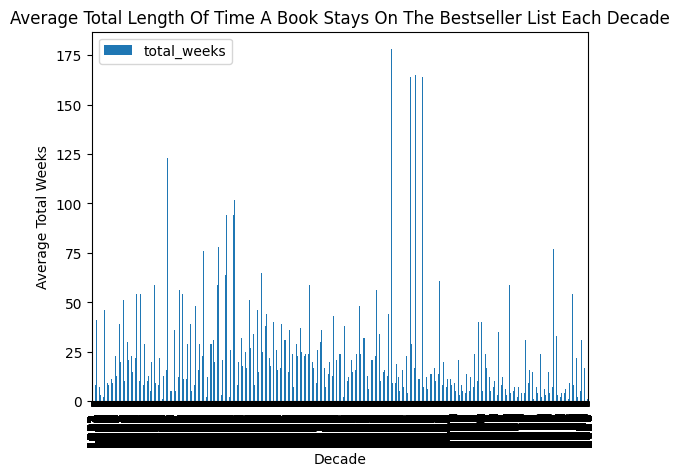

In [14]:
df2.plot.bar(x='year', y='total_weeks')
plt.title('Average Total Length Of Time A Book Stays On The Bestseller List Each Decade')
plt.xlabel('Decade')
plt.ylabel('Total Weeks')
plt.show()